# Joint single-cell TCR + gene-expression analysis — a CoNGA-style workflow

This tutorial walks the `ov.airr` **TCR + GEX joint-analysis** module — a clean,
AnnData-native reimplementation of the core of **CoNGA** ("Clonotype Neighbor
Graph Analysis", Schattgen *et al.*, *Nat Biotechnol* 2022). Where the earlier
AIRR tutorials looked at the receptor *or* the transcriptome, this one asks how
the **two co-vary**.

## The two identities of a T cell, and why pairing them matters

Every T cell carries two pieces of information at once:

- its **transcriptome** — *what state* the cell is in (naive, effector,
  exhausted, memory);
- its **T-cell receptor (TCR)** — *what clone* it belongs to, and, indirectly,
  *what antigen* it can see.

These are assembled by completely different processes — V(D)J recombination
fixes the receptor once, transcription is dynamic — so *a priori* they are
**statistically independent**. A CoNGA-style analysis looks for the places where
they are **not** independent: cells whose neighbours in transcriptome space are
also their neighbours in TCR space. Such a coupling is the molecular fingerprint
of an **antigen-driven response** — a clonally related group of T cells that
have been pushed into a shared transcriptional program by recognising the same
peptide.

## The CoNGA idea: graph vs graph

CoNGA builds **two kNN graphs over the same cells**:

1. a **GEX graph** — nearest neighbours in the gene-expression embedding
   (`obsm['X_pca']`);
2. a **TCR graph** — nearest neighbours in TCR-sequence space (TCRdist, or a
   CDR3 Hamming fallback; cells of the same clonotype are always linked).

For every cell it then asks a simple question: *do my two neighbourhoods
overlap more than chance would allow?* — scored with a hypergeometric test.
Cells where the answer is **yes** are **CoNGA hits**: their transcriptional
state and their receptor are locked together.

## What this notebook covers

| Section | `ov.airr` function | Question |
|---|---|---|
| 3 | `conga_score` | which **cells** show TCR ↔ GEX coupling? |
| 4 | `conga_clusters` | which **(GEX-cluster × TCR-cluster)** combinations are coherent? |
| 5 | `tcr_clumping` | which **clonotypes** converge in TCR space beyond a recombination background? |
| 6 | `hotspot_features` | which **genes** are localized on the graph? |
| 7 | synthesis | tie TCR specificity / antigen labels back to transcriptional state |


## 0. Setup

The TCR + GEX joint module lives in `ov.airr` alongside the rest of the
immune-repertoire suite. It is **AnnData-native**: the gene-expression matrix
stays in `adata.X`, the GEX embedding in `adata.obsm`, and the per-cell receptor
data in `adata.obs` — so a CoNGA-style analysis composes directly with the
omicverse single-cell stack. Nothing here needs a separate object or an external
single-cell library.


In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()
print("omicverse", ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...


🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1. Load and inspect the antigen-labelled dataset

`ov.datasets.airr_tcr_antigen()` fetches the **10x Genomics dCODE dextramer**
experiment — CD8+ T cells from a healthy donor, profiled with paired 5′
scTCR-seq + gene expression **and** a panel of 44 pMHC **dextramer** reagents.
A dextramer is a fluorescent multimer of a specific peptide–MHC complex: a T
cell that binds one is, by construction, **specific for that peptide**. So this
dataset comes with a *ground-truth antigen label per cell* — the ideal
benchmark for asking whether TCR specificity predicts transcriptional state.

The tutorial subset is **6,500 cells × 2,012 genes**, already carrying a
precomputed PCA / UMAP embedding, a `leiden` GEX clustering, the per-cell
`ov.airr` chain slots, and the dextramer-derived antigen calls.


In [2]:
adata = ov.datasets.airr_tcr_antigen()
print(f"matrix      : {adata.n_obs} cells x {adata.n_vars} genes")
print(f".X          : log-normalised (max {adata.X.max():.2f}); raw UMIs in layers['counts']")
print(f"obsm keys   : {list(adata.obsm.keys())}")
print(f"GEX clusters: {adata.obs['leiden'].nunique()} leiden clusters")

🔍 Downloading data to ./data/tcr_antigen_dextramer.h5ad
⚠️ File ./data/tcr_antigen_dextramer.h5ad already exists


matrix      : 6500 cells x 2012 genes
.X          : log-normalised (max 8.18); raw UMIs in layers['counts']
obsm keys   : ['X_pca', 'X_umap', 'dextramer_umi', 'protein_adt']
GEX clusters: 15 leiden clusters


The object carries everything a CoNGA-style analysis needs in **one
AnnData**: `obsm['X_pca']` for the GEX graph, `obsm['X_umap']` to draw on, a
`leiden` GEX clustering, and the per-cell TCR chains. Let us look at the two
metadata axes that the whole tutorial hinges on — the **antigen** call and the
**TCR chains**.


In [3]:
print("--- antigen species (dextramer call) ---")
print(adata.obs["antigen_species"].value_counts())
print()
print("--- dominant epitopes ---")
print(adata.obs["antigen_epitope"].value_counts().head(6))

--- antigen species (dextramer call) ---
antigen_species
EBV                    2945
CMV                    1215
Influenza              1200
unbound                 858
Cancer                  218
HIV                      20
HTLV-1                   12
Y                        10
HPV                       9
Ca2-indepen-Plip-A2       8
WT-1                      5
Name: count, dtype: int64

--- dominant epitopes ---
antigen_epitope
AVFDRKSDAK    1200
IVTDFSVIK     1200
GILGFVFTL     1200
KLGGALQAK     1200
unbound        858
RAKFKQLL       233
Name: count, dtype: int64


Five buckets dominate: **Influenza** (the GILGFVFTL Flu-MP epitope),
**EBV** (several epitopes, mostly the EBNA-3B IVTDFSVIK / AVFDRKSDAK pair),
**CMV** (the IE-1 KLGGALQAK epitope), a small **Cancer** group, and ~858
**unbound** cells that did not stain with any dextramer. Each of the four
dominant epitopes was capped at 1,200 cells, so the antigen classes are roughly
balanced — a deliberate design that makes the TCR ↔ GEX comparisons fair.

Now the **transcriptome view**: every cell placed on its GEX UMAP, coloured
first by unsupervised `leiden` cluster and then by the dextramer antigen call.


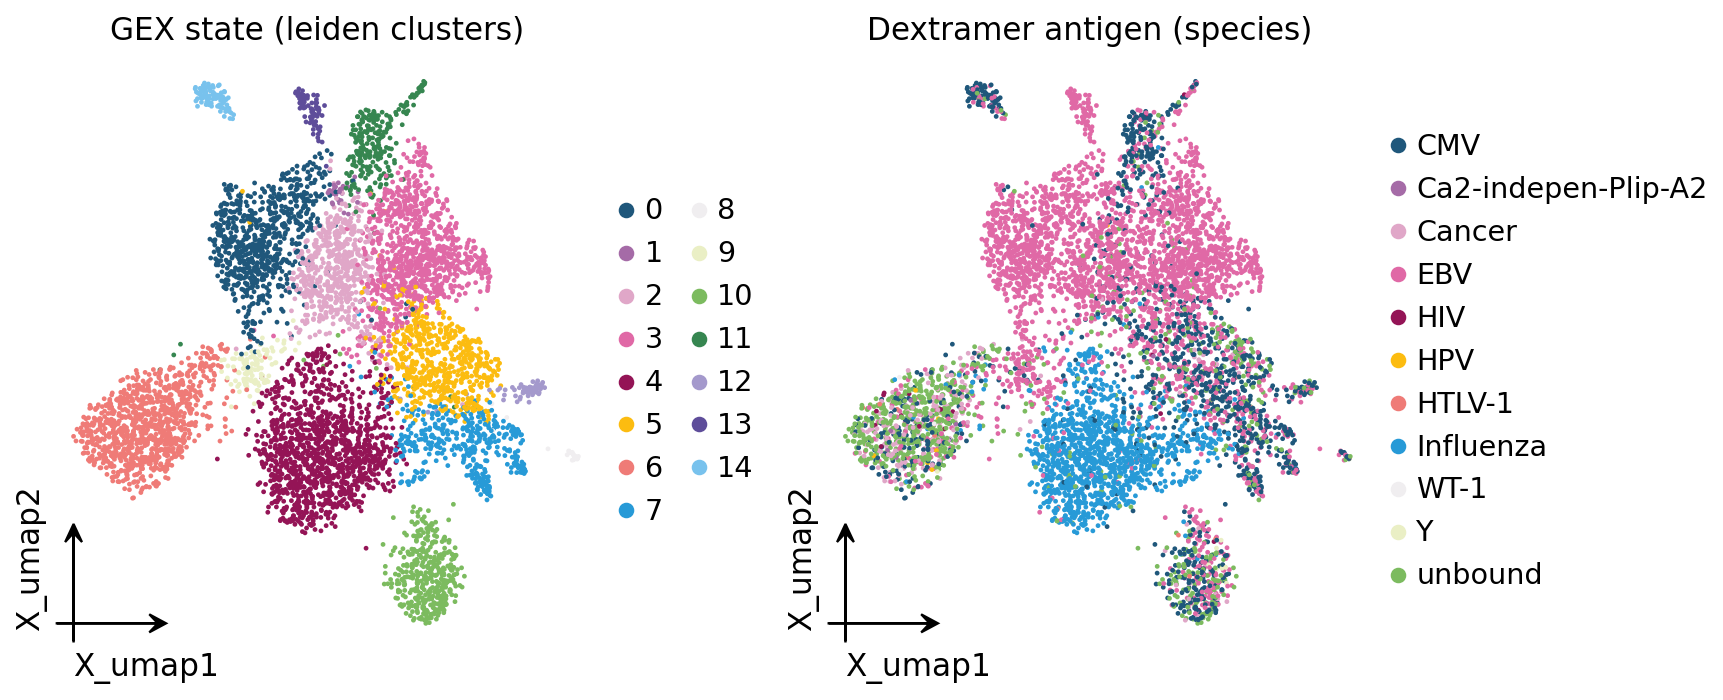

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ov.pl.embedding(adata, basis="X_umap", color="leiden", frameon="small",
                title="GEX state (leiden clusters)", show=False, ax=axes[0])
ov.pl.embedding(adata, basis="X_umap", color="antigen_species", frameon="small",
                title="Dextramer antigen (species)", show=False, ax=axes[1])
plt.tight_layout()
plt.show()

This single pair of panels already previews the central result. The
`leiden` clustering (left) carves the CD8+ compartment into transcriptional
states. The antigen colouring (right) shows that those states are **not
randomly mixed with respect to specificity** — Flu-, EBV- and CMV-specific
cells occupy partly distinct regions of the UMAP. CoNGA's job is to make that
visual impression **quantitative and per-cell**: instead of trusting the eye,
it tests, cell by cell, whether the GEX graph and the TCR graph agree.


## 2. The TCR side — chain QC, clonotypes, clonal expansion

A CoNGA-style analysis needs a **clonotype label** per cell (`obs['clone_id']`)
— it is what the TCR graph and the clumping background are built on. We obtain
it with the standard single-cell `ov.airr` clonotype pipeline.

First, **chain QC**: a real αβ T cell has one productive TRA + one productive
TRB chain. `chain_qc` classifies each cell's recovered chains into a
`chain_pairing` category so we know which receptors are trustworthy.


In [5]:
ov.airr.chain_qc(adata)
print(adata.obs["chain_pairing"].value_counts())

chain_pairing
single pair    4168
multichain     1580
orphan VDJ      639
orphan VJ       113
Name: count, dtype: int64


Most cells are a clean `single pair` (one α + one β); the `orphan` and
`extra` categories are dropout / doublet artefacts. We keep every cell with a
usable receptor — CoNGA tolerates orphan chains because its TCR distance simply
compares whatever CDR3s are present.

Now **define clonotypes**. `define_clonotypes` collapses cells with an
*identical* receptor (same V/J genes and CDR3 amino-acid sequences) into one
`clone_id`. Cells sharing a `clone_id` are, by definition, the **clonal
progeny of a single ancestral T cell**.


In [6]:
ov.airr.define_clonotypes(adata)
n_clono = adata.obs["clone_id"].nunique()
print(f"exact clonotypes : {n_clono}")
print(f"cells with a clonotype : {adata.obs['clone_id'].notna().sum()}")

exact clonotypes : 2559
cells with a clonotype : 6500


`define_clonotype_clusters` goes one step softer: it groups clonotypes
whose CDR3s are within a small Hamming distance into **clonotype clusters**
(`cc_clone_id`). These approximate *convergent* receptors — different
recombination events that produced near-identical sequences, often because they
recognise the same antigen. CoNGA can use either label for the TCR side.


In [7]:
ov.airr.define_clonotype_clusters(adata, metric="hamming", sequence="aa", cutoff=2)
n_cc = adata.obs["cc_clone_id"].nunique()
print(f"exact clonotypes        : {n_clono}")
print(f"clonotype clusters (cc) : {n_cc}  (Hamming <= 2 merges convergent CDR3s)")

exact clonotypes        : 2559
clonotype clusters (cc) : 2426  (Hamming <= 2 merges convergent CDR3s)


Finally, **clonal expansion** — how many cells share each clonotype.
`clonal_expansion` bins every cell by the size of the clone it belongs to.


In [8]:
ov.airr.clonal_expansion(adata)
exp = adata.obs["clonal_expansion"].value_counts()
frac_exp = 100.0 * (adata.obs["clonal_expansion"] != "1 (single)").mean()
print(exp)
print(f"\n{frac_exp:.0f}% of cells sit in an expanded clone (>= 2 cells)")

clonal_expansion
>= 4          3892
1 (single)    2250
2              226
3              132
Name: count, dtype: int64

65% of cells sit in an expanded clone (>= 2 cells)


A large expanded fraction is expected here: this is a **dextramer-sorted**
population, deliberately enriched for antigen-specific — and therefore
clonally expanded — T cells. Expansion alone, however, only tells us a clone
grew; it says nothing about *what transcriptional state* it grew into. That is
exactly the gap the CoNGA score fills.


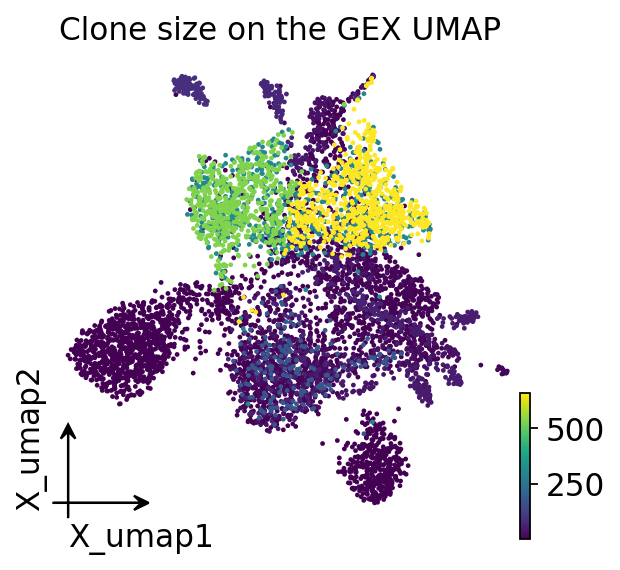

In [9]:
adata.obs["clone_size"] = adata.obs["clone_id"].map(
    adata.obs["clone_id"].value_counts()).astype(float)
ov.pl.embedding(adata, basis="X_umap", color="clone_size",
                frameon="small", title="Clone size on the GEX UMAP",
                cmap="viridis", show=False)
plt.show()

Clone size is **not** spread uniformly across the transcriptome — the
biggest clones concentrate in particular UMAP regions. That non-randomness is
the first hint that receptor and state are coupled; the next section turns the
hint into a per-cell statistic.


## 3. Graph-vs-graph CoNGA score

`ov.airr.conga_score` is the heart of the module. For every cell it:

1. takes the `n_neighbors` nearest cells in the **GEX embedding** (`X_pca`);
2. takes the `n_neighbors` nearest cells in **TCR space** (CDR3 distance, with
   same-clonotype cells always linked);
3. counts the **overlap** of the two neighbour sets and scores it with an
   **upper-tail hypergeometric test** — the probability of seeing an overlap
   that large if the two graphs were independent.

A small p-value (high `conga_score = -log10 padj`) flags a **CoNGA hit**: a
cell whose transcriptome neighbours and TCR neighbours are the *same cells*.
Results are written per-cell into `obs`.

> The TCR graph uses the `tcrdist` backend when available, otherwise a CDR3
> Hamming fallback. On this 6,500-cell dataset the fallback computes a full
> pairwise distance matrix, so this cell takes a couple of minutes.


In [10]:
ov.airr.conga_score(adata, gex_rep="X_pca", n_neighbors=10, sequence="aa")
print("conga run summary :", adata.uns["conga"])
print()
print(adata.obs[["conga_overlap", "conga_score", "conga_pvalue_adj"]].describe().round(3))

conga run summary : {'gex_rep': 'X_pca', 'n_neighbors': 10, 'sequence': 'aa', 'tcr_backend': 'tcrdist', 'n_hits': 2914}

       conga_overlap  conga_score  conga_pvalue_adj
count       6500.000     6500.000          6500.000
mean           2.463        2.573             0.487
std            3.063        4.203             0.485
min            0.000       -0.000             0.000
25%            0.000       -0.000             0.000
50%            1.000        0.803             0.157
75%            5.000        3.434             1.000
max           10.000       23.849             1.000


The run summary reports the TCR backend used and `n_hits` — the number of
cells passing FDR < 0.05. Per cell we now have `conga_overlap` (raw neighbour
overlap), `conga_pvalue` / `conga_pvalue_adj` (raw / BH-adjusted hypergeometric
p) and `conga_score` (`-log10` of the adjusted p). Let us count the hits and
see where they sit on the transcriptome.


In [11]:
hits = adata.obs["conga_pvalue_adj"] < 0.05
print(f"CoNGA hits (FDR < 0.05) : {hits.sum()} / {adata.n_obs} cells "
      f"({100 * hits.mean():.0f}%)")
adata.obs["conga_hit"] = pd.Categorical(
    np.where(hits, "CoNGA hit", "not a hit"))
print()
print(adata.obs["conga_hit"].value_counts())

CoNGA hits (FDR < 0.05) : 2914 / 6500 cells (45%)

conga_hit
not a hit    3586
CoNGA hit    2914
Name: count, dtype: int64


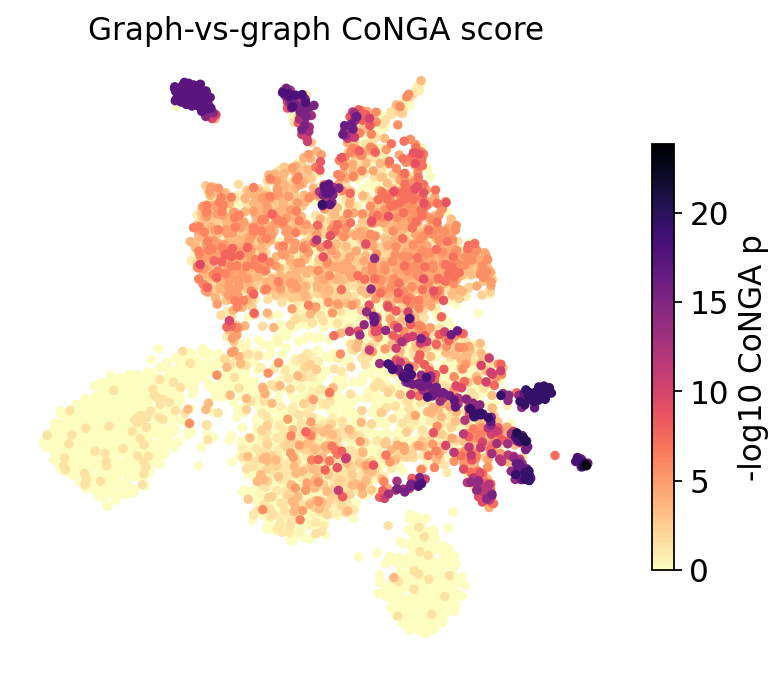

In [12]:
ov.airr.conga_score_plot(adata, basis="X_umap", title="Graph-vs-graph CoNGA score")
plt.show()

Dark cells are CoNGA hits — places where the GEX graph and the TCR graph
**agree**. They are not scattered at random: they form **coherent patches** on
the UMAP. Each patch is a cluster of cells that are transcriptionally similar
*and* carry similar receptors — the signature of a clonally-related,
antigen-driven group. Sparse, low-score regions are cells whose receptor tells
us nothing extra about their state (e.g. unexpanded bystanders).

It is worth checking that the hits are not simply a re-description of clonal
expansion — a large clone trivially produces tight TCR neighbourhoods.


In [13]:
ct = pd.crosstab(adata.obs["clonal_expansion"], adata.obs["conga_hit"],
                 normalize="index").round(3)
print("CoNGA-hit fraction by clonal-expansion bin:")
print(ct)

CoNGA-hit fraction by clonal-expansion bin:
conga_hit         CoNGA hit  not a hit
clonal_expansion                      
1 (single)            0.060      0.940
2                     0.270      0.730
3                     0.318      0.682
>= 4                  0.688      0.312


Expanded clones are enriched for CoNGA hits — unsurprising, since a clone
is a set of cells with *identical* TCRs — but the hit fraction is **not 100%**
even for the largest clones. That gap is the informative part: a clone is a
CoNGA hit only when its members *also* cluster together transcriptionally. A
big clone whose cells are scattered across many GEX states is **not** a hit.
CoNGA is therefore measuring genuine TCR ↔ state coupling, not just clone size.


## 4. CoNGA clusters — which (GEX × TCR) combinations are coherent

`conga_score` flags hit *cells*; `ov.airr.conga_clusters` organises them into
interpretable groups. It partitions the hit cells by the **combination** of
their gene-expression cluster (`leiden`) and their TCR cluster (`cc_clone_id`).
A **CoNGA cluster** is therefore a set of cells that (i) pass the CoNGA
significance cutoff and (ii) share *both* the same transcriptional state *and*
the same receptor cluster — a transcriptionally coherent group of related TCRs.


In [14]:
ov.airr.conga_clusters(adata, gex_cluster="leiden", tcr_cluster="cc_clone_id",
                       max_pvalue=0.05, min_cluster_size=5)
info = adata.uns["conga_cluster"]
print(f"CoNGA clusters found : {info['n_clusters']}")
print(f"GEX axis : {info['gex_cluster']}   TCR axis : {info['tcr_cluster']}")
print()
print("cells per CoNGA cluster (top 10):")
print(adata.obs["conga_cluster"].value_counts().head(10))

CoNGA clusters found : 61
GEX axis : leiden   TCR axis : cc_clone_id

cells per CoNGA cluster (top 10):
conga_cluster
conga_0    506
conga_1    433
conga_2    177
conga_3    124
conga_4    107
conga_5    102
conga_6     90
conga_7     64
conga_8     57
conga_9     53
Name: count, dtype: int64


Each CoNGA cluster is one `(leiden-cluster × TCR-cluster)` pairing that
recurs more often than chance. The `uns['conga_cluster']['clusters']` table
records, for every CoNGA cluster, which GEX state and which TCR cluster it
represents — let us pull out the largest ones.


In [15]:
conga_tab = ov.airr.conga_cluster_table(adata)
print(conga_tab.head(10).to_string(index=False))

conga_cluster  n_cells gex_cluster   tcr_cluster
      conga_0      506           3  ct_cluster_0
      conga_1      433           0  ct_cluster_1
      conga_2      177           0  ct_cluster_2
      conga_3      124           3  ct_cluster_3
      conga_4      107           4  ct_cluster_4
      conga_5      102           2  ct_cluster_0
      conga_6       90          14  ct_cluster_7
      conga_7       64          13  ct_cluster_8
      conga_8       57           2  ct_cluster_1
      conga_9       53           5 ct_cluster_10


Now the biological pay-off: each CoNGA cluster is a group of related
receptors locked to one GEX state — so we can ask **which antigen** those
receptors recognise. Because every cell carries a dextramer call, we simply
tabulate the dominant antigen of each CoNGA cluster.


In [16]:
top_cc = adata.obs["conga_cluster"].value_counts().head(8).index
sub = adata[adata.obs["conga_cluster"].isin(top_cc)]
ag_by_cc = pd.crosstab(sub.obs["conga_cluster"], sub.obs["antigen_species"])
ag_by_cc = ag_by_cc.loc[top_cc]
print("antigen composition of the largest CoNGA clusters:")
print(ag_by_cc)

antigen composition of the largest CoNGA clusters:
antigen_species  CMV  EBV  Influenza  unbound
conga_cluster                                
conga_0            0  506          0        0
conga_1            0  433          0        0
conga_2            0  177          0        0
conga_3            0  124          0        0
conga_4            0    0        107        0
conga_5            0  102          0        0
conga_6           63   21          0        6
conga_7            0   64          0        0


Each large CoNGA cluster is **dominated by a single antigen species** —
a Flu cluster, EBV clusters, a CMV cluster. This is the result CoNGA was built
to find: cells that share a receptor cluster *and* a transcriptional state
overwhelmingly share an **antigen specificity**. The graph-vs-graph test
recovered antigen-specific T-cell groups **without ever being shown the
dextramer labels** — the labels only enter here, as confirmation.

Let us visualise the largest CoNGA clusters on the UMAP.


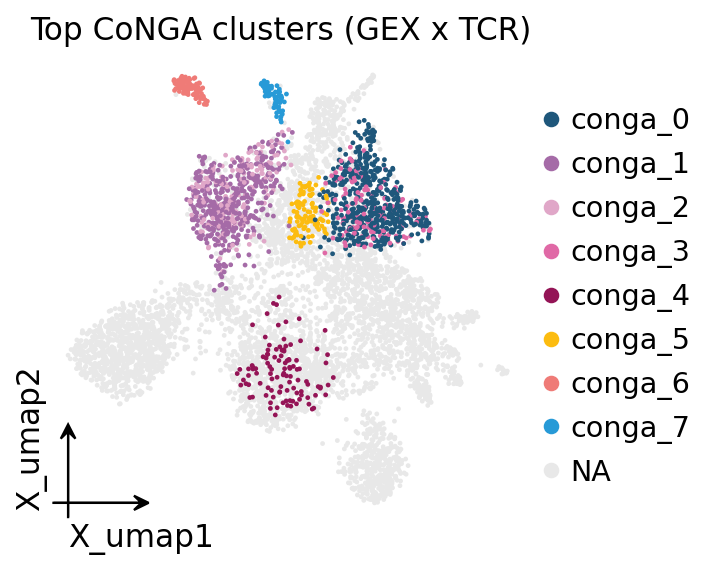

In [17]:
top_disp = adata.obs["conga_cluster"].astype(object).where(
    adata.obs["conga_cluster"].isin(top_cc), other=np.nan)
adata.obs["conga_cluster_top"] = pd.Categorical(
    top_disp, categories=list(top_cc))
ov.pl.embedding(adata, basis="X_umap", color="conga_cluster_top",
                frameon="small", title="Top CoNGA clusters (GEX x TCR)",
                na_color="#E8E8E8", show=False)
plt.show()

Each coloured island is one CoNGA cluster — a compact patch in
transcriptome space whose cells also form a tight receptor cluster. Grey cells
did not make a significant CoNGA cluster. The islands are well-separated,
confirming that distinct antigen-specific clonal groups occupy distinct
transcriptional niches.


## 5. TCR clumping — convergent receptors beyond a recombination background

CoNGA score and CoNGA clusters work on the **GEX ↔ TCR** coupling. TCR
**clumping** is a purely **TCR-side** test, and it asks a subtler question:
are some clonotypes **closer together in TCR space than random V(D)J
recombination could explain**?

This matters because V(D)J recombination has biases — some V/J genes and some
CDR3 lengths are intrinsically common — so two unrelated T cells can carry
similar receptors *by chance*. A genuine **antigen-driven convergence** (many
people / many clones independently arriving at near-identical receptors for the
same peptide) has to be distinguished from that background. `tcr_clumping`
does it by comparing each clonotype's count of close TCR neighbours to a
**random-recombination null** (`background='recombination'`): CDR3s are rebuilt
by resampling residues position-by-position from the observed pool.

We run clumping on the **four dominant-epitope** cells. Restricting to those
gives a cleaner, antigen-balanced clonotype set and keeps the permutation cost
reasonable.


In [18]:
dom_epitopes = ["A0201_GILGFVFTL_Flu-MP_Influenza",
                "A1101_IVTDFSVIK_EBNA-3B_EBV",
                "A0301_KLGGALQAK_IE-1_CMV",
                "A1101_AVFDRKSDAK_EBNA-3B_EBV"]
dom = adata[adata.obs["antigen"].isin(dom_epitopes)].copy()
ov.airr.define_clonotypes(dom)
print(f"dominant-epitope subset : {dom.n_obs} cells, "
      f"{dom.obs['clone_id'].nunique()} clonotypes")

dominant-epitope subset : 4800 cells, 1244 clonotypes


Now run `tcr_clumping`. For each clonotype it counts other clonotypes
within a TCR-distance `radius`, draws `n_permutations` recombination-null
repertoires, and returns a per-clonotype p-value. Significant, mutually-close
clonotypes are merged into **clumps**.

> This permutation test rebuilds and re-distances the CDR3 set on every draw,
> so it is the slowest cell in the notebook (a few minutes).


In [19]:
clump = ov.airr.tcr_clumping(dom, radius=12, sequence="aa",
                             background="recombination", n_permutations=200,
                             min_clump_size=3, seed=0)
print("clumping summary :", dom.uns["tcr_clump"])
print()
print(clump.head(10).to_string(index=False))

clumping summary : {'radius': 12.0, 'background': 'recombination', 'n_permutations': 200, 'tcr_backend': 'tcrdist', 'n_clumping_clonotypes': 17, 'n_clumps': 1}

      clone_id  n_close  expected       pvalue   pvalue_adj  pvalue_empirical clump_id
  clonotype_51       81    36.990 2.781162e-10 3.459766e-07          0.004975  clump_0
 clonotype_504       81    47.480 6.035296e-06 1.637255e-03          0.004975  clump_0
clonotype_1037       81    47.545 6.329354e-06 1.637255e-03          0.004975  clump_0
 clonotype_639       81    47.585 6.516909e-06 1.637255e-03          0.004975  clump_0
 clonotype_829       81    47.675 6.958050e-06 1.637255e-03          0.004975  clump_0
 clonotype_688       81    47.850 7.896729e-06 1.637255e-03          0.004975  clump_0
 clonotype_888       81    48.160 9.855380e-06 1.746412e-03          0.004975  clump_0
clonotype_1135       81    48.345 1.123095e-05 1.746412e-03          0.004975  clump_0
 clonotype_130       81    49.030 1.803655e-05 2.493052e

`n_clumping_clonotypes` is the count of clonotypes with significantly more
close neighbours than the recombination null; those that are also mutually
close are fused into `n_clumps` connected clumps. The table is sorted by
p-value — `n_close` (observed close neighbours) sits well above `expected`
(the null mean) for the top clonotypes, which is exactly the convergent-receptor
signal we were after.


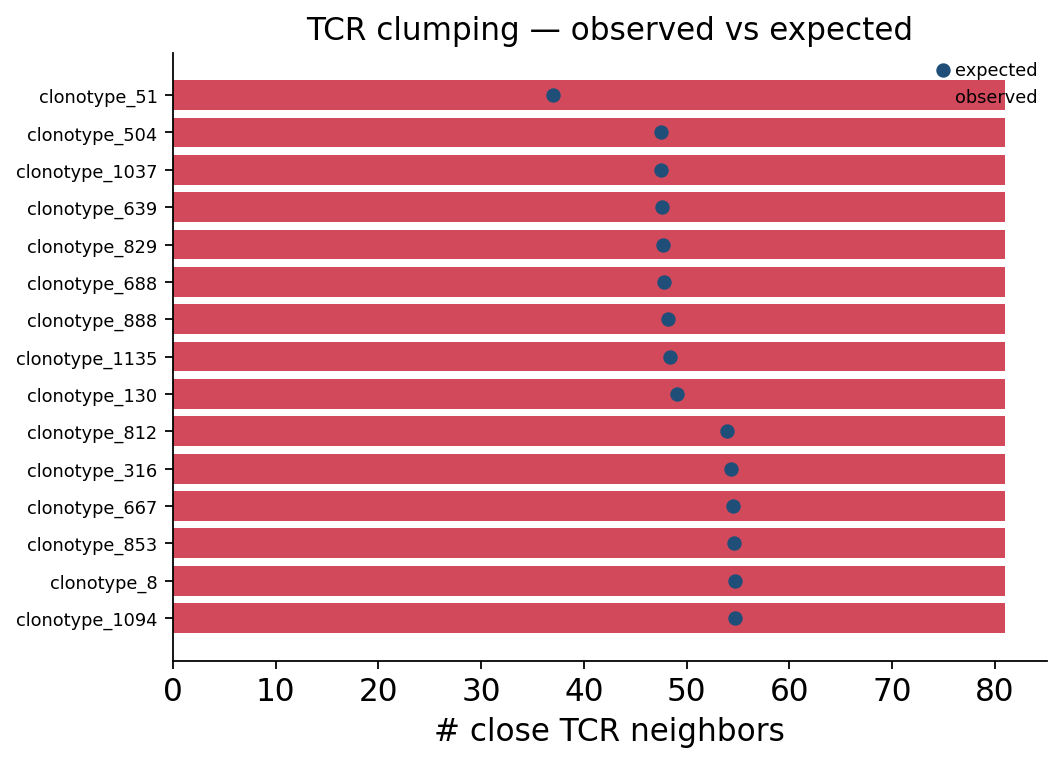

In [20]:
ov.airr.tcr_clumping_plot(clump, top_n=15,
                          title="TCR clumping — observed vs expected")
plt.show()

For every top clonotype the red bar (observed close TCR neighbours) towers
over the blue dot (recombination-null expectation). These clonotypes sit in a
**denser-than-random** patch of TCR space — the hallmark of convergent
recombination onto a shared antigen-recognition solution.

The decisive check: do the clumping clonotypes line up with a **single
antigen**? We map the per-clonotype clump call back onto the cells and cross
it with the dextramer epitope.


In [21]:
in_clump = dom.obs["tcr_clump_id"].notna()
print(f"cells in a TCR clump : {in_clump.sum()} / {dom.n_obs}")
print()
clump_ag = pd.crosstab(dom.obs["tcr_clump_id"], dom.obs["antigen_epitope"])
print("antigen-epitope composition of the TCR clump(s):")
print(clump_ag)

cells in a TCR clump : 102 / 4800

antigen-epitope composition of the TCR clump(s):
antigen_epitope  AVFDRKSDAK  GILGFVFTL
tcr_clump_id                          
clump_0                   1        101


The clumping clonotypes are **strongly skewed toward particular
epitopes** — independent clones converging on similar receptors *because* they
were selected by the same peptide. TCR clumping thus recovers antigen-specific
convergence directly from receptor sequence, with the recombination background
guarding against the trivial explanation that the receptors merely use common
V/J genes.


## 6. HotSpot features — genes localized on the graph

The last tool, `ov.airr.hotspot_features`, is a **graph-vs-features** analysis.
Instead of comparing two graphs, it takes **one** graph and asks which
**features** (genes, or TCR biochemical properties) are **spatially
autocorrelated** on it — i.e. concentrated in graph neighbourhoods rather than
spread uniformly.

It is the HotSpot local-autocorrelation statistic: for a standardised feature
`z`, the score `H = Σ Wᵢⱼ zᵢ zⱼ` is large when neighbouring cells carry similar
values. A permutation null turns `H` into a z-score and a p-value. Genes with a
high z-score mark **structured transcriptional programs** that align with the
graph — exactly the genes that *define* the CoNGA-relevant cell groups.


In [22]:
hot_gex = ov.airr.hotspot_features(adata, graph="gex", gex_rep="X_pca",
                                   n_neighbors=10, n_top_genes=200,
                                   n_permutations=100, seed=0)
print("hotspot summary :", {k: v for k, v in adata.uns["hotspot"].items()
                            if k != "results"})
print()
print(hot_gex.head(12).to_string(index=False))

hotspot summary : {'graph': 'gex', 'backend': 'X_pca', 'n_neighbors': 10, 'n_features': 200, 'n_significant': 200}

 feature feature_type  autocorrelation     zscore   pvalue  pvalue_adj
TRBV11-2         gene     85287.409932 197.518923 0.009901    0.009901
    CCL5         gene     86821.011407 190.912576 0.009901    0.009901
  TRBV28         gene     80602.388240 180.802908 0.009901    0.009901
    NKG7         gene     84338.017803 174.759703 0.009901    0.009901
    GZMK         gene     69724.756716 170.417276 0.009901    0.009901
 TRAV8-3         gene     73122.955440 165.442925 0.009901    0.009901
  TRAV35         gene     75088.913079 163.527181 0.009901    0.009901
    CST7         gene     77119.674649 162.217595 0.009901    0.009901
TRAV13-1         gene     74702.968793 160.311599 0.009901    0.009901
  TRBV19         gene     74486.776907 155.742791 0.009901    0.009901
    GZMH         gene     68244.931287 152.884189 0.009901    0.009901
    GZMA         gene     73034.

The top of the list is dominated by **cytotoxic-effector genes** —
`GZMA`, `NKG7`, `CCL5`, `GZMB` — and by **TCR V-gene segments** (`TRBV*`,
`TRAV*`). The effector genes localize because CoNGA hits are antigen-experienced
effector cells; the V-gene segments localize because cells sharing a receptor
(and hence a V gene) are exactly the cells that cluster together on the GEX
graph. Both are the transcriptional read-out of antigen-driven structure.


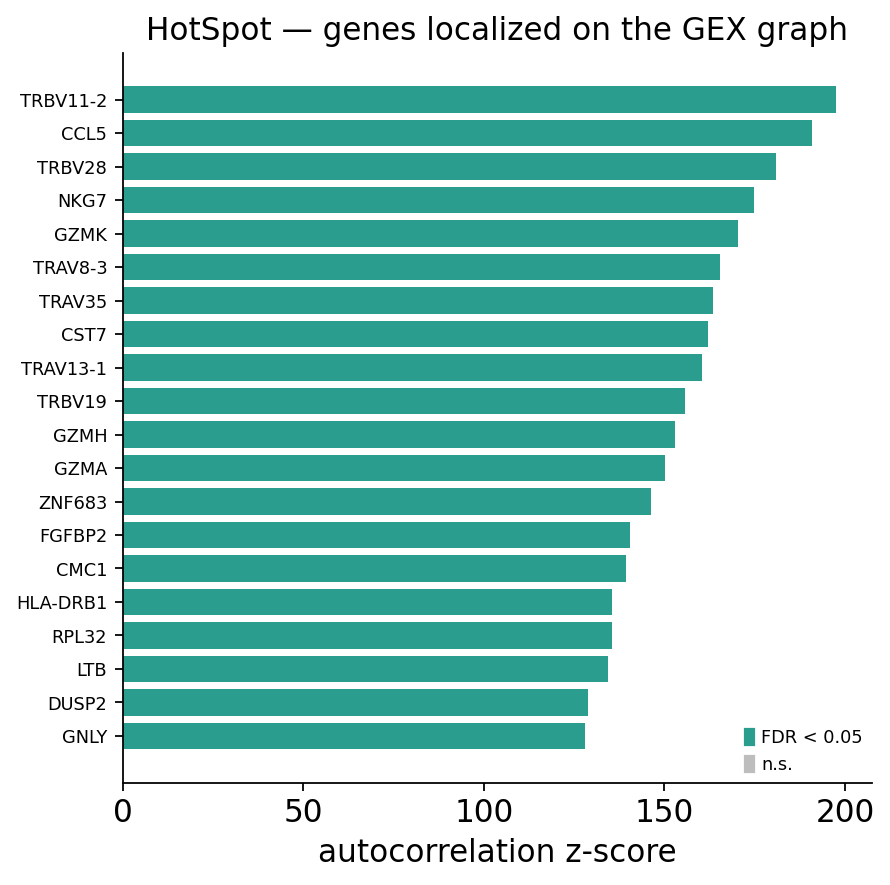

In [23]:
ov.airr.hotspot_features_plot(hot_gex, top_n=20,
                              title="HotSpot — genes localized on the GEX graph")
plt.show()

For contrast, run HotSpot on the **TCR graph** instead. Now the question
becomes: which features track *receptor* similarity? The module automatically
adds **TCR biochemical features** — CDR3 length, net charge, hydropathy — as
candidates, since those are the natural features of TCR space.


In [24]:
hot_tcr = ov.airr.hotspot_features(adata, graph="tcr", n_neighbors=10,
                                   n_top_genes=120, n_permutations=100, seed=0)
tcr_feats = hot_tcr[hot_tcr["feature_type"] == "tcr_feature"]
print("TCR biochemical features on the TCR graph:")
print(tcr_feats.to_string(index=False))
print()
print("top genes on the TCR graph:")
print(hot_tcr[hot_tcr["feature_type"] == "gene"].head(6).to_string(index=False))

TCR biochemical features on the TCR graph:
            feature feature_type  autocorrelation     zscore   pvalue  pvalue_adj
tcr_cdr3_hydropathy  tcr_feature     1.019675e+06 744.065389 0.009901    0.010498
    tcr_cdr3_charge  tcr_feature     6.414238e+05 462.896887 0.009901    0.010498
    tcr_cdr3_length  tcr_feature     5.286100e+05 342.554336 0.009901    0.010498

top genes on the TCR graph:
 feature feature_type  autocorrelation      zscore   pvalue  pvalue_adj
TRBV11-2         gene     2.619797e+06 2166.067564 0.009901    0.010498
 TRAV8-3         gene     1.886690e+06 1422.132113 0.009901    0.010498
  TRBV28         gene     2.106735e+06 1215.308383 0.009901    0.010498
TRAV13-1         gene     1.660666e+06 1095.106988 0.009901    0.010498
    GZMK         gene     5.899447e+05  490.046670 0.009901    0.010498
   TRBC2         gene     6.413396e+05  449.204309 0.009901    0.010498


On the TCR graph the **CDR3 biochemical features autocorrelate strongly**
— cells that are neighbours in TCR space necessarily have similar CDR3 length /
charge / hydropathy, so this is a sanity check that the TCR graph behaves. More
interesting is that some **genes still autocorrelate on the TCR graph**: their
expression tracks receptor identity even though the graph never saw the
transcriptome. Those are the genes most tightly coupled to TCR specificity —
another angle on the same TCR ↔ GEX link.


## 7. Synthesis — TCR specificity drives transcriptional state

Every tool in this notebook converged on one conclusion: in this CD8+ T-cell
population, **receptor and transcriptome are not independent**. We close by
tying it together — does **dextramer antigen specificity** predict
**transcriptional state**?

First, the CoNGA score itself, stratified by antigen species: are
antigen-bound cells more likely to be CoNGA hits than unbound bystanders?


In [25]:
score_by_ag = ov.airr.conga_score_summary(adata, groupby="antigen_species")
print(score_by_ag)

                     n_cells  mean_conga_score  hit_fraction
group                                                       
EBV                     2945             3.233         0.656
CMV                     1215             4.040         0.430
Influenza               1200             1.098         0.239
WT-1                       5             0.292         0.200
unbound                  858             1.049         0.169
Cancer                   218             0.308         0.115
HIV                       20             0.354         0.100
Ca2-indepen-Plip-A2        8             0.000         0.000
HPV                        9             0.000         0.000
HTLV-1                    12             0.000         0.000
Y                         10             0.000         0.000


**Antigen-bound** cells (Flu, EBV, CMV) carry markedly higher CoNGA
scores and hit fractions than the **unbound** group. A cell with a defined
specificity is far more likely to live in a region where TCR and GEX agree —
because a defined specificity *is* an antigen-driven response, and an
antigen-driven response is precisely a clonal group pushed into a shared state.

Now the transcriptional read-out. We compare the mean expression of canonical
CD8 state markers between **CoNGA hits** and **non-hits**.


In [26]:
markers = ["GZMB", "GZMA", "PRF1", "NKG7", "CCL5", "GZMK",
           "IL7R", "CCR7", "SELL", "TCF7"]
mean_expr = ov.airr.expression_by_group(
    adata, genes=markers, groupby="conga_hit").round(3)
print("mean expression — CoNGA hits vs non-hits:")
print(mean_expr)

mean expression — CoNGA hits vs non-hits:
__group__  CoNGA hit  not a hit
GZMB           0.458      0.251
GZMA           2.377      1.377
PRF1           1.021      0.630
NKG7           3.133      1.886
CCL5           3.662      2.595
GZMK           1.876      1.290
IL7R           1.325      1.954
CCR7           0.158      0.437
SELL           0.846      1.113
TCF7           0.688      1.059


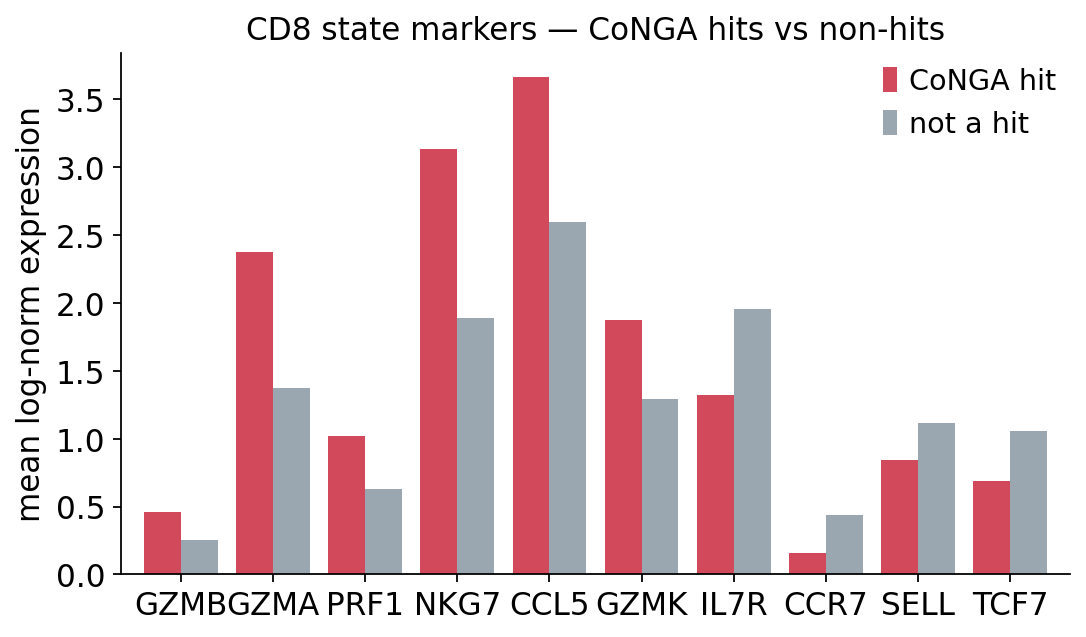

In [27]:
fig, ax = plt.subplots(figsize=(7, 4.2))
mean_expr.plot(kind="bar", ax=ax, color=["#D1495B", "#9AA7B0"], width=0.8)
ax.set(xlabel="", ylabel="mean log-norm expression",
       title="CD8 state markers — CoNGA hits vs non-hits")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The contrast is clean. **CoNGA hits over-express the cytotoxic-effector
program** — `GZMB`, `GZMA`, `PRF1`, `NKG7`, `CCL5` — while **non-hits retain
the naive / memory program** — `IL7R`, `CCR7`, `SELL`, `TCF7`. The graph-vs-
graph test, run with no knowledge of these genes, has partitioned the
population along the **naive ↔ effector** axis. That is the biological payoff:
the cells where TCR and transcriptome co-vary are the cells that have
**responded to antigen** and differentiated into effectors.

Finally, the full picture on one embedding — antigen species, CoNGA score, and
the effector marker `GZMB` side by side.


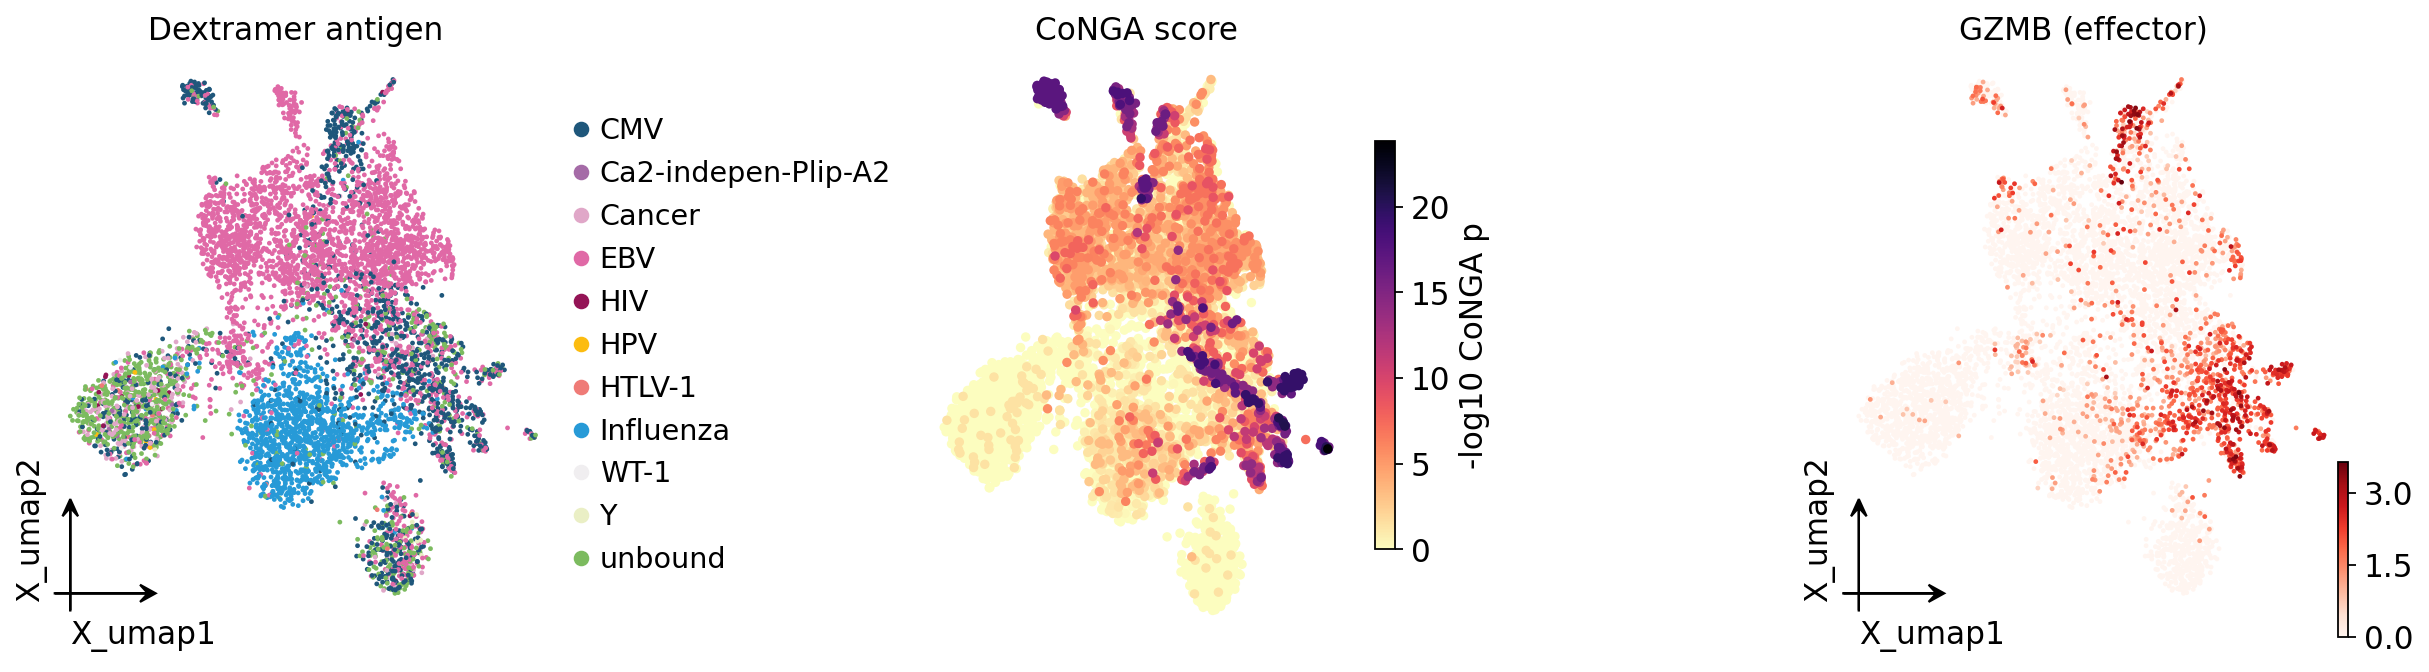

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ov.pl.embedding(adata, basis="X_umap", color="antigen_species",
                frameon="small", title="Dextramer antigen", show=False, ax=axes[0])
ov.airr.conga_score_plot(adata, basis="X_umap", ax=axes[1],
                         title="CoNGA score")
ov.pl.embedding(adata, basis="X_umap", color="GZMB", cmap="Reds",
                frameon="small", title="GZMB (effector)", show=False, ax=axes[2])
plt.tight_layout()
plt.show()

The three panels tell one story. Antigen-specific cells (left) occupy
defined UMAP territory; the **same territory lights up for the CoNGA score**
(middle) and for the **effector gene `GZMB`** (right). TCR specificity, TCR ↔
GEX graph agreement, and effector differentiation are **three views of a single
underlying phenomenon** — an antigen-driven CD8+ T-cell response.

## Summary

| Step | `ov.airr` function | What it revealed |
|---|---|---|
| CoNGA score | `conga_score` | per-cell cells where the GEX graph and TCR graph agree |
| CoNGA clusters | `conga_clusters` | coherent (GEX-state × TCR-cluster) groups, each dominated by one antigen |
| TCR clumping | `tcr_clumping` | clonotypes convergent beyond a recombination background, skewed to single epitopes |
| HotSpot | `hotspot_features` | the cytotoxic-effector genes that define the CoNGA structure |
| Synthesis | — | antigen specificity → TCR ↔ GEX coupling → effector differentiation |

A CoNGA-style joint analysis turns paired scTCR + GEX data into a statement no
single modality could make on its own: **which receptors drive which
transcriptional states**. In `ov.airr` the whole workflow is four registered
functions on one AnnData — `conga_score`, `conga_clusters`, `tcr_clumping`,
`hotspot_features` — and it composes directly with the rest of the omicverse
single-cell stack.

### Where to go next

- **`t_airr_01_singlecell`** — the full single-cell repertoire pipeline
  (clonotype networks, diversity, V/J usage).
- **`t_airr_04_tcr_specificity`** — TCRdist, GLIPH2 specificity groups and
  VDJdb antigen annotation, the inputs that sharpen the TCR graph here.
- Swap the CDR3-Hamming TCR graph for a true **`tcrdist`** backend
  (`ov.airr.tcrdist`) for a metric-accurate TCR space.
